In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_pareto_front
from optuna.importance import get_param_importances
from optuna.samplers import RandomSampler
from Testing.RTLO import *
from Testing.Cloud import *
from Testing.AutoCloud import *
from Functions.RLS import *
from Functions.Utils import *

from Functions.TedaGraphs import *

dir_hi = r"C:\Artigo_J3C_V2\VMD10\HI"
dir_rs = r"C:\Artigo_J3C_V2\VMD10\RS6_def\S2_A1_Q10_W10_RS_raw\RS1"
brng = 'Bearing1_1.csv'
brngs1 = ['Bearing1_1.csv','Bearing2_2.csv','Bearing1_2.csv','Bearing1_3.csv','Bearing2_5.csv']
Mp=[1.9249999999999998, 10, 8, True]
Mp2 = [1e-7,	0.1,	0.01,	1e-7,	18,	3,	24]
m, nRS, st, drop = Mp
D,N1, N2, N3,nHI, nR,tau = Mp2

In [4]:
def objective(trial):
    m = trial.suggest_float('m', 1.4, 2.0,step=0.005)
    nRS = trial.suggest_int('nRS', 1, 15) 
    st = trial.suggest_int('st', 0, 10) 
    drop = trial.suggest_categorical('drop', [False, False]) 
    brngs = brngs1[:2]
    vgrnls,ngrnls = np.array([]),np.array([])
    init = (st+nRS)
    Grncreated = None
    lenRun=0

    for i,brng in enumerate(brngs):
        df_RS = (pd.read_csv(os.path.join(dir_rs,brng)).abs()).iloc[:,:-1]
        df_HI = (pd.read_csv(os.path.join(dir_hi,brng)).abs()).iloc[:,:-1]
        if drop: df_RS = df_RS.drop(columns='Y')
        RS = process_RS(df_RS,nRS)
        HI = process_HI(df_HI,nHI=nHI,init=init)
        xS,yS,zS = RS[st:-2], HI[:-1], HI[1:]

        if i==0: teda=AutoCloud(m=m, nS=len(xS[0]), nI=len(yS[0]), nR=nR, nO=len(yS[0]), 
                            ηS= [N1, N2, N3], tau=tau, decay=D,eol=0.2,fator=1,
                            st=init,end=len(df_RS)-init,wta=True,ep=0.1) 
        
        elif i>0: teda.reset_rul()

        for j,_ in enumerate(xS):
            x= xS[j]
            teda.run(X=x)
                
        #if i == 0: 
        Grncreated = len(teda.c)
        trial.report(Grncreated, step=j + lenRun)
        if trial.should_prune(): raise optuna.TrialPruned()

    for cloud in teda.c[:]:
        cloud.calc_Dmax(teda.xR,teda.xF)
        cloud.calc_v(k=teda.k)
        vgrnls = np.append(vgrnls,cloud.v*cloud.n)
        ngrnls = np.append(ngrnls,cloud.n)
    return np.sum(vgrnls)/np.sum(ngrnls)
pruner=optuna.pruners.ThresholdPruner(upper=6, lower=2)
study = optuna.create_study(
    direction="maximize",
    #storage="sqlite:///" + f'98_Optuna/{FileName}_Grnls.db',
    #study_name=f'P{7}',
    #sampler=RandomSampler(),
    pruner=pruner,
    load_if_exists=True)
study.optimize(objective, n_trials=500)
best_params = study.best_params
Mp = list(best_params.values())
print('Erro:', study.best_value, 'parameters: ', Mp)


[I 2026-03-11 16:26:48,371] A new study created in memory with name: no-name-7e707329-da4b-41de-bedc-954cfcc0052f
[I 2026-03-11 16:26:48,377] Trial 0 pruned. 
[I 2026-03-11 16:26:48,382] Trial 1 pruned. 
[I 2026-03-11 16:26:48,397] Trial 2 finished with value: 0.40598985431841833 and parameters: {'m': 1.4249999999999998, 'nRS': 13, 'st': 4, 'drop': False}. Best is trial 2 with value: 0.40598985431841833.
[I 2026-03-11 16:26:48,401] Trial 3 pruned. 
[I 2026-03-11 16:26:48,407] Trial 4 pruned. 
[I 2026-03-11 16:26:48,411] Trial 5 pruned. 
[I 2026-03-11 16:26:48,415] Trial 6 pruned. 
[I 2026-03-11 16:26:48,420] Trial 7 pruned. 
[I 2026-03-11 16:26:48,432] Trial 8 finished with value: 0.44708680142687274 and parameters: {'m': 1.42, 'nRS': 15, 'st': 10, 'drop': False}. Best is trial 8 with value: 0.44708680142687274.
[I 2026-03-11 16:26:48,438] Trial 9 pruned. 
[I 2026-03-11 16:26:48,451] Trial 10 finished with value: 0.4466223246135552 and parameters: {'m': 1.43, 'nRS': 15, 'st': 10, 'drop

ValueError: shapes (134,30) and (134,30) not aligned: 30 (dim 1) != 134 (dim 0)

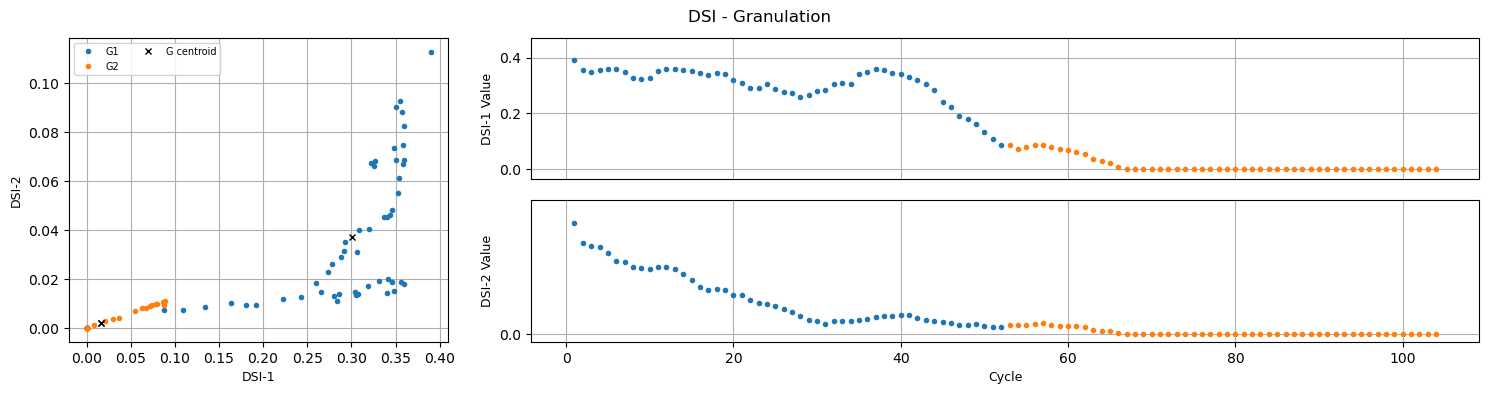

In [14]:
init = (st+nRS)
df_RS = (pd.read_csv(os.path.join(dir_rs,brng)).abs()).iloc[:,:-1]
df_HI = (pd.read_csv(os.path.join(dir_hi,brng)).abs()).iloc[:,-1:]
if drop: df_RS = df_RS.drop(columns='Y')
RS = process_RS(df_RS,nRS)
HI = process_HI(df_HI,nHI=nHI,init=init)
xS,yS,zS = RS[st:-2], HI[:-1], HI[1:]

teda=AutoCloud(m=m, nS=len(xS[0]), nI=len(yS[0]), nR=nR, nO=len(yS[0]), 
                            ηS= [N1, N2, N3], tau=tau, decay=D,eol=0.2,
                            fator=1,st=init,end=len(df_RS)-init,wta=True,ep=0.1) 

for j,_ in enumerate(xS[:]):
    x,y,z= xS[j],yS[j],zS[j]
    teda.run(x)
    #teda.adapt(y,z)
    #teda.RUL_uncertainty(y,z)
    #teda.AddRUL()

#plot_2series(x1=teda.cycleP,x2=teda.cycleP,y1=teda.rulR,y2=teda.rulP, title=brng,s1='True',s2='Pred')
plot_DSI2(teda,ftrs=2,title='DSI - Granulation',ncol=2)
#plot_series(series=[[x,x,x,x],[yL,yP,yU,yR]],names=['L','P','U','R'],show=False)
#plot_RUL_CI(teda,startX=20,endX=120,endY=165)

In [ ]:
def objective(trial):
    m, nRS, st, drop= Mp
    init = (st+nRS)
    nHI = trial.suggest_int('nHI', 1, init) 
    nR = trial.suggest_int('nR', 1, 30) 
    #N1 = trial.suggest_float('N1', 8e-4, 6e-3, log=True)
    #N2 = trial.suggest_float('N2', 4e-4, 1e-2, log=True)
    #N3 = trial.suggest_float('N3', 1e-14, 1e-6, log=True)
    #N1 = trial.suggest_float('N1', 1e-10, 1e-2, log=True)
    #N2 = trial.suggest_float('N2', 1e-10, 1e-2, log=True)
    #N3 = trial.suggest_float('N3', 1e-10, 1e-2, log=True)
    #D = trial.suggest_float('D', 1e-10, 1e-0, log=True)

    N1 = trial.suggest_categorical('N1', [1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1]) 
    N2 = trial.suggest_categorical('N2', [1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1]) 
    N3 = trial.suggest_categorical('N3', [1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1]) 
    D = trial.suggest_categorical('D', [1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1])
    tau = trial.suggest_int('tau', 1, 30)
    #fator = trial.suggest_float('fator', 0.95, 1.05, step=0.01)
    erro = np.array([])
    brngs = brngs1[0:3]
    len_ = 0
    for i,brng in enumerate(brngs):
        mapeInit,check = None, False
        df_RS = (pd.read_csv(os.path.join(dir_rs,brng)).abs()).iloc[:,:-1]
        df_HI = (pd.read_csv(os.path.join(dir_hi,brng)).abs()).iloc[:,-1:]
        if drop: df_RS = df_RS.drop(columns='Y')
        xS = process_RS(df_RS, nRS)[st:]
        RS = process_RS(df_RS,nRS)
        HI = process_HI(df_HI,nHI=nHI,init=init)
        xS,yS,zS = RS[st:-2], HI[:-1], HI[1:]

        if i==0: 
            teda=AutoCloud(m=m, nS=len(xS[0]), nI=len(yS[0]), nR=nR, nO=len(yS[0]), 
                            ηS=[N1,N2,N3], tau=tau, decay=D,
                            eol=0.2, fator=1,st=init,end=len(df_RS)-init,wta=True,ep=0.1) 
        elif i>0: teda.reset_rul()
        teda.win_all=True
        teda.add_rulR2(n=-(st+nRS)+len(df_RS))

        for j,_ in enumerate(xS):
            x,y,z= xS[j],yS[j],zS[j]
            teda.run(X=x,MergeGrnls=True,MergeOffGrnls=True,FitOffGrnls=True,OfflineRun=True)
            teda.adapt(y,z)
            teda.RUL_single(y, Scut=150)

            if i ==0:
                if np.any(1 != teda.cloud_activation2[-1]) and not check:
                    mapeInit=j
                    check = True
                    DamagedGrnl = (teda.cloud_activation2[-1])
            elif i>0 and not check:
                if DamagedGrnl in teda.cloud_activation3[-1]:
                    mapeInit = j+0
                    check = True

            if j == int(len(xS)*0.25):  # checkpoint de avaliação
                trial.report(teda.rulP[-1], step=j+len_)
                if trial.should_prune():
                    raise optuna.TrialPruned()

        #print(lGrnl)
        mape = teda.MAPE(start=mapeInit,rulR=teda.rulR2)
        erro = np.append(erro,mape)
        len_ = len_ + len(df_RS)
    MAPE = np.mean(erro)
    return MAPE

K = K +1
pruner=optuna.pruners.ThresholdPruner(upper=160, lower=2)
#sampler = optuna.samplers.TPESampler(multivariate=True,group=True,seed=1,n_startup_trials=2500)
sampler = optuna.samplers.TPESampler(multivariate=True,group=True,n_startup_trials=2500)
#sampler=RandomSampler()
study = optuna.create_study(
    direction="minimize",
    storage="sqlite:///" + f'Optuna/{FileName}_Prdct.db',
    study_name=f'P{6}',
    sampler=sampler,
    pruner=pruner,
    load_if_exists=True)
study.optimize(objective, n_trials=5000)
best_params = study.best_params
Mp2 = list(best_params.values())
print('Erro:', study.best_value, 'parameters: ', Mp2)
